In [2]:
import networkx as nx

def find_mdst(G):
    """
    Finds the Absolute Center and Minimum Diameter Spanning Tree of an unweighted graph.
    """
    # 1. Compute All-Pairs Shortest Paths (APSP)
    # Using dictionary comprehension for $O(n^2)$ lookup efficiency
    apsp = dict(nx.all_pairs_shortest_path_length(G))

    min_radius = float('inf')
    absolute_center = None
    is_edge_center = False

    # 2. Check all vertices for their eccentricity
    for v in G.nodes():
        eccentricity = max(apsp[v].values())
        if eccentricity < min_radius:
            min_radius = eccentricity
            absolute_center = v
            is_edge_center = False

    # 3. Check all edge midpoints for their eccentricity
    for u, v in G.edges():
        # Distance from an edge midpoint to any node w is min(d(u,w), d(v,w)) + 0.5
        edge_eccentricity = max(min(apsp[u][w], apsp[v][w]) + 0.5 for w in G.nodes())
        if edge_eccentricity < min_radius:
            min_radius = edge_eccentricity
            absolute_center = (u, v)
            is_edge_center = True

    # 4. Construct the Spanning Tree
    if not is_edge_center:
        # If the center is a vertex, a simple BFS tree suffices
        mdst = nx.bfs_tree(G, absolute_center).to_undirected()
    else:
        # If the center is on an edge, we subdivide the edge with a dummy node,
        # run BFS from the dummy node, and then replace the dummy with the original edge.
        u, v = absolute_center
        G_temp = G.copy()
        G_temp.remove_edge(u, v)
        dummy_node = 'TEMP_CENTER'
        G_temp.add_edge(u, dummy_node)
        G_temp.add_edge(v, dummy_node)

        mdst_temp = nx.bfs_tree(G_temp, dummy_node).to_undirected()

        # Clean up the dummy node to restore the original graph structure in the tree
        mdst_temp.remove_node(dummy_node)
        mdst_temp.add_edge(u, v)
        mdst = mdst_temp

    return mdst, absolute_center, min_radius

# --- Example Usage ---
# Generate a random 3-regular graph (which is likely an expander)
n_nodes = 100
G = nx.random_regular_graph(3, n_nodes)

# Ensure it is connected
if nx.is_connected(G):
    tree, center, radius = find_mdst(G)
    print(f"Absolute Center: {center}")
    print(f"Tree Radius from Center: {radius}")

    # The diameter of the resulting tree will be roughly 2 * radius
    tree_diameter = nx.diameter(tree)
    print(f"Resulting MDST Diameter: {tree_diameter}")
else:
    print("Graph is not connected. MDST cannot be formed.")

Absolute Center: 0
Tree Radius from Center: 7
Resulting MDST Diameter: 14


Absolute Center: (0, 19)


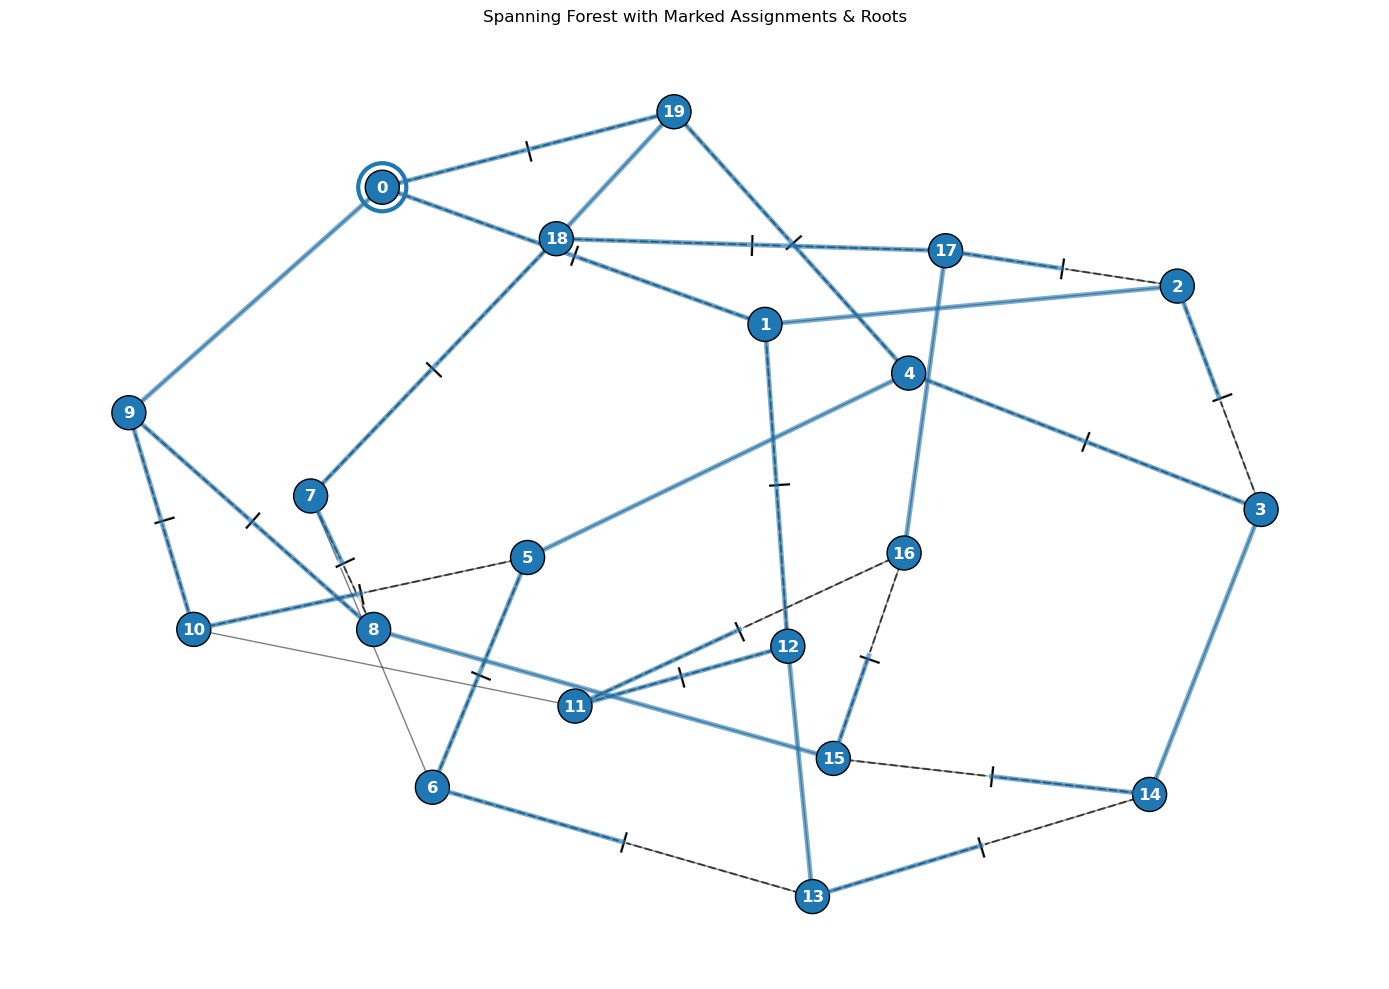

In [18]:
from spidercat.draw import draw_spanning_forest_solution
from spidercat.spanning_tree import find_min_height_roots, match_forest_leaves_to_marked_edges
from spidercat.utils import load_solution_triplet

grf, forest, M, matchings = load_solution_triplet(20, 5, 1)
tree, center, radius = find_mdst(grf)
print(f"Absolute Center: {center}")

matchings = match_forest_leaves_to_marked_edges(tree, M)
draw_spanning_forest_solution(grf, tree, M, matchings, {0: center[0] if isinstance(center, tuple) else center})


In [16]:
M

{(0, 39): 1,
 (0, 1): 1,
 (1, 2): 1,
 (2, 27): 1,
 (3, 4): 1,
 (3, 15): 1,
 (4, 33): 1,
 (5, 6): 1,
 (5, 11): 1,
 (6, 7): 1,
 (7, 8): 1,
 (8, 16): 1,
 (9, 10): 1,
 (9, 24): 1,
 (10, 30): 1,
 (11, 12): 1,
 (12, 13): 1,
 (13, 35): 1,
 (14, 15): 1,
 (14, 20): 1,
 (16, 17): 1,
 (17, 18): 1,
 (18, 26): 1,
 (19, 20): 1,
 (19, 32): 1,
 (21, 22): 1,
 (21, 34): 1,
 (22, 23): 1,
 (23, 29): 1,
 (24, 25): 1,
 (25, 26): 1,
 (27, 28): 1,
 (28, 38): 1,
 (29, 30): 1,
 (31, 32): 1,
 (31, 37): 1,
 (33, 34): 1,
 (35, 36): 1,
 (36, 37): 1,
 (38, 39): 1,
 (0, 17): 0,
 (1, 12): 0,
 (2, 3): 0,
 (4, 5): 0,
 (6, 22): 0,
 (7, 36): 0,
 (8, 9): 0,
 (10, 11): 0,
 (13, 14): 0,
 (15, 16): 0,
 (18, 19): 0,
 (20, 21): 0,
 (23, 24): 0,
 (25, 39): 0,
 (26, 27): 0,
 (28, 29): 0,
 (30, 31): 0,
 (32, 33): 0,
 (34, 35): 0,
 (37, 38): 0}

In [ ]:
So m